In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


### Handle Missing Values

In [4]:
categorical_cols = df.select_dtypes(include = "object").columns
numerical_cols = df.select_dtypes(include = "number").columns

In [5]:
print(categorical_cols)
numerical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')


Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [6]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [7]:
df.head()
df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [8]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

### EDA (Exploratory Data Analysis

Text(0.5, 1.0, 'Is Loan Approved or not?')

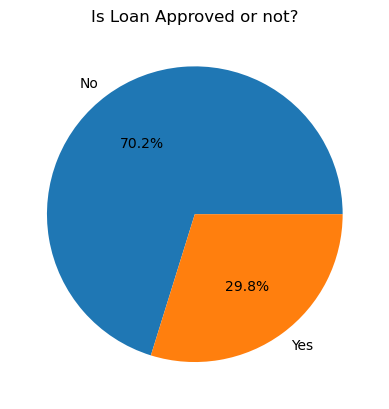

In [9]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is Loan Approved or not?")


[Text(0, 0, '722'), Text(0, 0, '278')]

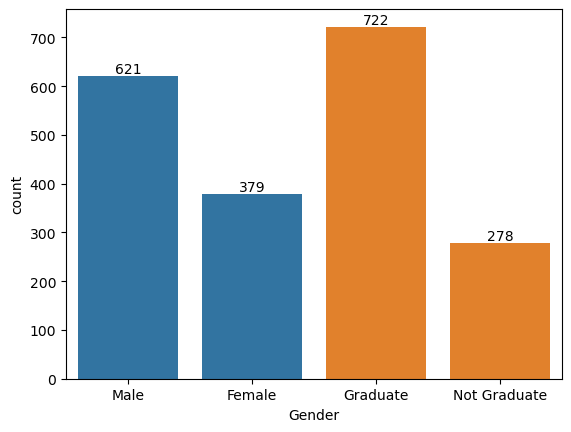

In [10]:
# analysis categories

gender_count = df["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

education_count = df["Education_Level"].value_counts()
ax = sns.barplot(education_count)
ax.bar_label(ax.containers[1])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

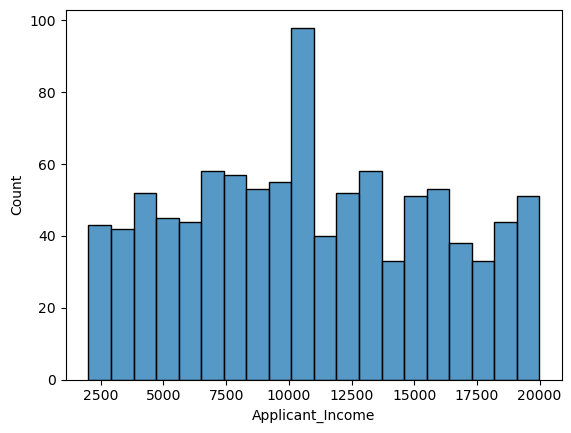

In [11]:
# analysis income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins =20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

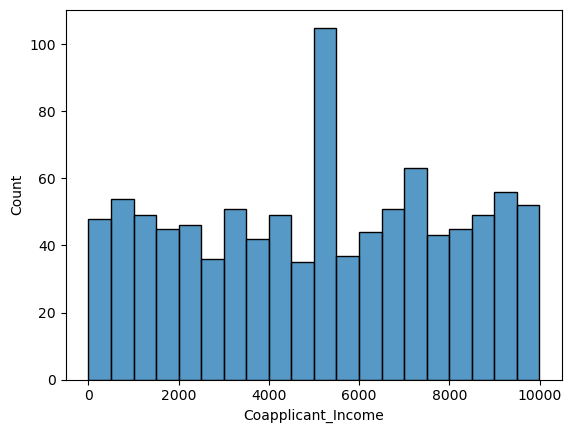

In [12]:
# analysis co-applicant income

sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins =20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

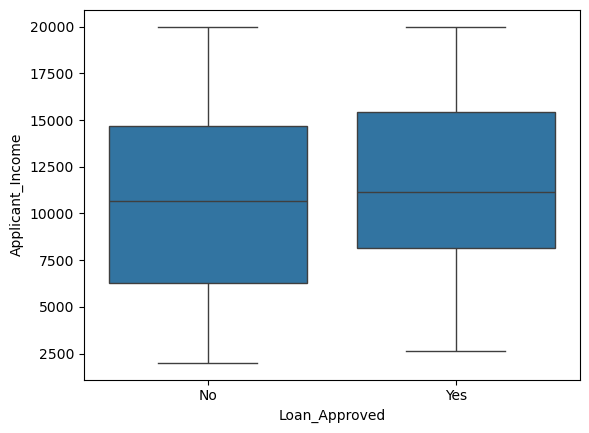

In [13]:
# Outliers - Box Plots:

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)


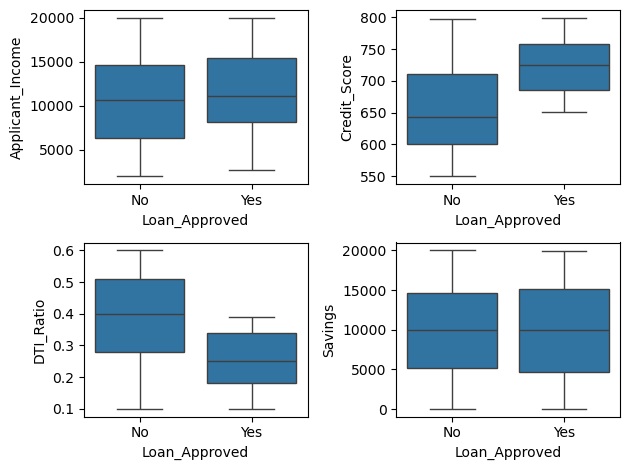

In [14]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax=axes[0,1],data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax=axes[1,0],data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax=axes[1,1],data = df,x = "Loan_Approved",y = "Savings")

plt.tight_layout()

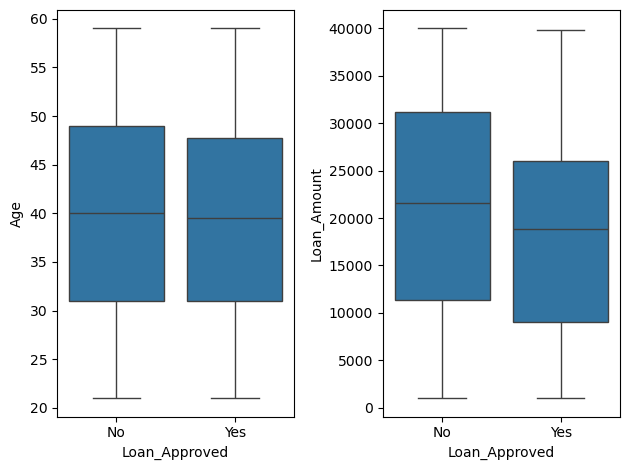

In [15]:
fig, axes = plt.subplots(1, 2)

sns.boxplot(ax=axes[0], data=df, x="Loan_Approved", y="Age")
sns.boxplot(ax=axes[1], data=df, x="Loan_Approved", y="Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

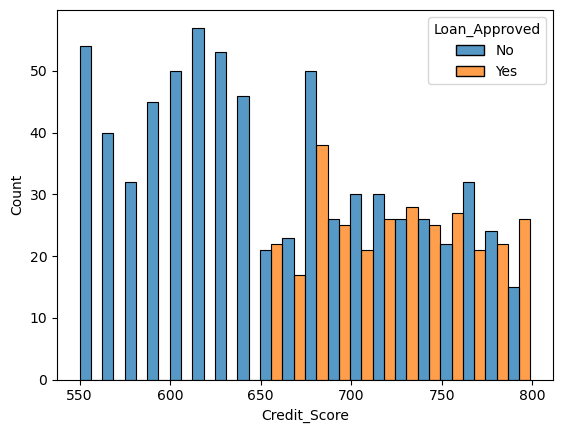

In [16]:
# Relation --> Credit Score with Loan Approved

sns.histplot(
    data = df,
    x = "Credit_Score",
    hue= "Loan_Approved",
    bins =20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

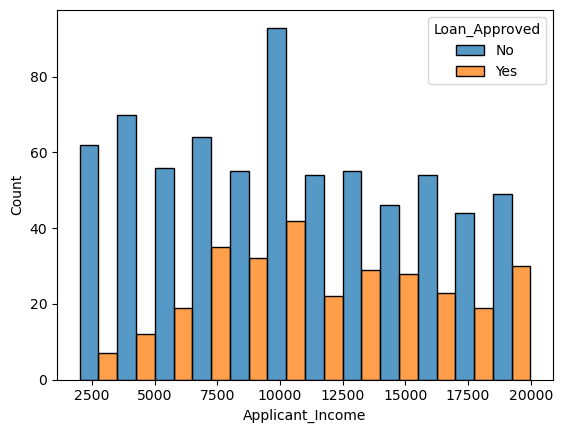

In [17]:
# Relation --> Applicant_Income with Loan Approved
sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    multiple = "dodge"
)

In [23]:
# Remove Applicant_ID: Its given by Bank so it is not necessary yo keep

df = df.drop("Applicant_ID",axis=1, errors="ignore")

In [22]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
